# Multimodal AutoML LOOCV — MSN × FC coupling  [지역 · Spearman]

MSN(형태 유사도)과 FC(기능 연결)를 **같은 DK cortical 68 ROI**로 맞춰서 결합한다.
뼈대(6개 모델 · LOOCV · nested GridSearchCV · fold 안에서 residualize → PCA)는
`../automl_comparison_paired_multimodal_morphPCA_FCtop2.ipynb`와 동일하다.

## 데이터 (루트의 CSV를 `../`로 읽음)

| 파일 | 내용 | 만든 곳 |
|---|---|---|
| `msn_strength_68.csv` | MSN regional MS 68개 | `build_msn_dataset.py` |
| `fc_strength_68.csv` | FC strength 68개 (피질 67개 파트너 평균) | `build_fc_dataset.py` |
| `msn_full_68x68.csv`, `fc_full_68x68.csv` | edge 2278개씩 → coupling 계산에만 사용 | 같음 |

## 표본
MSN 45명 ∩ FC 44명 = **공통 44명** (sub-001은 FC 없음). 타겟 `vas_t1`, 임상 `vas_t0` + `treatment_group`.

## 피처셋 (Clinical 2개는 항상 포함)

| Data Type | 뇌 피처 | nuisance (fold 안 train에서만 fit) |
|---|---|---|
| `Clinical_ONLY` | 없음 | — |
| `MSN_PCA3` | MSN strength 68 → PCA 3 | age, sex, eTIV |
| `FC68_PCA3` | FC strength 68 → PCA 3 | age, sex, mean_fd |
| `Multimodal` | MSN PCA3 + FC68 PCA3 | 모달리티별로 따로 |
| `Coupling_S_PCA3` | ROI별 MSN–FC coupling(Spearman) 68 → PCA 3 | age, sex, eTIV, mean_fd |

PCA 성분 수 3은 기존 멀티모달 노트북과 맞춘 **사전 고정값**이다. 결과를 보고 바꾸지 않는다.

## Coupling이란
피험자마다, ROI i마다:
- MSN 행렬의 i행 = ROI i가 나머지 67개 ROI와 **얼마나 닮았나** (형태)
- FC 행렬의 i행 = ROI i가 같은 67개 ROI와 **얼마나 같이 움직이나** (기능)
- 이 67쌍의 Pearson r = **ROI i의 구조–기능 결합도**

두 행렬의 ROI가 순서까지 같아야 i행끼리 짝을 지을 수 있다. 이것이 68×68 매칭이 필요한 이유다.
vas를 쓰지 않고 피험자 안에서만 계산하므로 CV 밖에서 미리 계산해도 leakage가 없다.


---
## 이 노트북의 coupling 정의 — 지역 · Spearman

ROI마다 MSN 행과 FC 행(자기 제외 67개)의 **순위 상관**을 구한다. 사람당 68개가 나오고 PCA 3개로 줄인다.

- **모델에 들어가는 coupling 피처: PCA 3개**
- `treatment_group`은 기존 노트북과 같이 **임상 피처에 포함**한다 (기존 결과와 비교하기 위함).

`_PCA3.ipynb`와 **정의가 딱 하나 다르다**: `np.corrcoef` → `spearmanr`.
둘의 결과가 같으면 극단값 탓이 아니라는 근거가 되고, 갈리면 Spearman 쪽을 믿는다.

### 같은 폴더의 다른 변형

| 파일 | coupling |
|---|---|
| `..._coupling_PCA3.ipynb` | 지역 · Pearson → PCA 3 |
| `..._coupling_PCA5.ipynb` | 지역 · Pearson → PCA 5 |
| `..._coupling_PCA3_spearman.ipynb` | 지역 · Spearman → PCA 3 |
| `..._coupling_global_pearson.ipynb` | 전역 · Pearson (1개) |
| `..._coupling_global_spearman.ipynb` | 전역 · Spearman (1개) |

네 변형은 피험자 간 상관이 r > 0.95로 서로 매우 닮았다(vas를 보지 않고 확인).
따라서 **셋 이상에서 같은 방향**이 나와야 신호로 읽고, 하나만 튀면 노이즈로 본다.
좋은 변형만 골라 보고하면 그 자체가 leakage다.


In [1]:
import os
# joblib 병렬 처리시 비-ASCII 경로에서 UnicodeEncodeError 나는 것 회피.
# LOCALAPPDATA는 사용자 이름(한글)이 들어가 있어 안 되므로 ASCII 경로를 직접 쓴다 (FC 노트북과 동일).
os.environ['JOBLIB_TEMP_FOLDER'] = r'C:\SUDMEX\jltmp'
os.makedirs(os.environ['JOBLIB_TEMP_FOLDER'], exist_ok=True)

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION  (MSN 68 + FC 68, rid 기준 결합)
# ==========================================================
DATA_DIR = '..'   # 데이터 CSV는 TMS 루트에 있다

def load(name):
    d = pd.read_csv(os.path.join(DATA_DIR, name), skipinitialspace=True)
    d.columns = d.columns.str.strip()
    return d

msn_s = load('msn_strength_68.csv')   # 앞 7열: rid, treatment_group, vas_t0, vas_t1, age, sex, eTIV
fc_s  = load('fc_strength_68.csv')    # 앞 7열: ... mean_fd
msn_e = load('msn_full_68x68.csv')
fc_e  = load('fc_full_68x68.csv')

# --- ROI 매칭 확인: 접미사만 떼면 이름과 순서가 같아야 한다 ---
ROIS = [c[:-len('_msn')] for c in msn_s.columns[7:]]
assert len(ROIS) == 68, len(ROIS)
assert [c[:-len('_fc')] for c in fc_s.columns[7:]] == ROIS, 'strength ROI 순서 불일치'
msn_edge_cols, fc_edge_cols = list(msn_e.columns[7:]), list(fc_e.columns[7:])
assert [c[:-len('_msn')] for c in msn_edge_cols] == fc_edge_cols, 'edge 순서 불일치'

# --- 임상 변수는 두 파일 모두 structural CSV에서 왔으므로 공통 44명에서 같아야 한다 ---
chk = msn_s.merge(fc_s, on='rid', suffixes=('_m', '_f'))
for c in ['treatment_group', 'vas_t0', 'vas_t1', 'age', 'sex']:
    assert np.allclose(chk[f'{c}_m'], chk[f'{c}_f']), c

# --- rid inner join: 공통 44명 ---
df = (msn_s.merge(fc_s[['rid', 'mean_fd'] + list(fc_s.columns[7:])], on='rid', how='inner')
      .sort_values('rid').reset_index(drop=True))
assert len(df) == 44, len(df)

# edge 표도 df와 같은 rid 순서로 맞춘다
E_msn = msn_e.set_index('rid').loc[df['rid'], msn_edge_cols].values   # (44, 2278)
E_fc  = fc_e.set_index('rid').loc[df['rid'], fc_edge_cols].values     # (44, 2278)

# ---- ROI별 structure–function coupling (44 x 68) ----
IU = np.triu_indices(68, k=1)
OFF = ~np.eye(68, dtype=bool)

def to_matrix(edge_row):
    M = np.zeros((68, 68))
    M[IU] = edge_row
    return M + M.T          # 대각은 OFF로 빼고 쓰므로 0으로 둔다

def coupling(msn_edges, fc_edges):
    """ROI i: MSN i행과 FC i행(자기 자신 제외 67개)의 Spearman rho.

    순위 상관을 쓰는 이유: MSN edge는 measure 8개로 만든 상관이라 |r| > 0.9가 7.9%로 흔하다.
    순위는 이런 극단값에 덜 휘둘리고, 단조 변환에 불변이라 FC를 r로 쓰든 Fisher z로 쓰든 같다.
    """
    S, F = to_matrix(msn_edges), to_matrix(fc_edges)
    return np.array([spearmanr(S[i, OFF[i]], F[i, OFF[i]]).statistic for i in range(68)])

X_coup = np.array([coupling(E_msn[k], E_fc[k]) for k in range(len(df))])
assert np.all(np.isfinite(X_coup))

X_msn      = df[[f'{r}_msn' for r in ROIS]].values
X_fc       = df[[f'{r}_fc' for r in ROIS]].values
X_nuis_msn = df[['age', 'sex', 'eTIV']].values
X_nuis_fc  = df[['age', 'sex', 'mean_fd']].values
X_nuis_cp  = df[['age', 'sex', 'eTIV', 'mean_fd']].values   # coupling은 두 모달리티의 교란을 다 받는다
X_clinical = df[['vas_t0', 'treatment_group']].values
y          = df['vas_t1'].values
group      = np.where(df['treatment_group'].values == 2, 'Active', 'Sham')

print(f'n = {len(df)}  |  Active {int((group == "Active").sum())} / Sham {int((group == "Sham").sum())}')
print(f'MSN strength {X_msn.shape[1]} | FC strength {X_fc.shape[1]} | coupling {X_coup.shape[1]}')
print(f'coupling 전체 평균 {X_coup.mean():+.3f} (SD {X_coup.std():.3f}) | '
      f'피험자별 전뇌 평균 {X_coup.mean(1).min():+.3f} ~ {X_coup.mean(1).max():+.3f}')

n = 44  |  Active 25 / Sham 19
MSN strength 68 | FC strength 68 | coupling 68
coupling 전체 평균 +0.166 (SD 0.220) | 피험자별 전뇌 평균 +0.067 ~ +0.263


In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP  (기존 노트북과 동일)
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]
    },
}

N_PCA = 3   # 세 모달리티 모두 사전 고정 (기존 멀티모달 노트북과 동일)

DATA_TYPES = ['Clinical_ONLY', 'MSN_PCA3', 'FC68_PCA3', 'Multimodal', 'Coupling_S_PCA3']

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
#    fold 내부: 모달리티별 nuisance residualization → scale → PCA → stack → StandardScaler
#    ※ 5 datasets x 6 models x 44 folds — 수 분 ~ 수십 분 소요
# ==========================================================
def resid_pca(X, N, tr, te):
    """nuisance 회귀 잔차 → 표준화 → PCA(N_PCA). 전부 train에서만 fit."""
    reg = LinearRegression().fit(N[tr], X[tr])
    X_tr = X[tr] - reg.predict(N[tr])
    X_te = X[te] - reg.predict(N[te])
    sc = StandardScaler().fit(X_tr)
    pca = PCA(n_components=N_PCA, random_state=42).fit(sc.transform(X_tr))
    return (pca.transform(sc.transform(X_tr)), pca.transform(sc.transform(X_te)),
            pca.explained_variance_ratio_.sum())

loo = LeaveOneOut()
predictions     = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
evr_log = {'MSN': [], 'FC68': [], 'Coupling': []}
y_true = []

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets x {len(y)} folds ...\n")

for fold_idx, (tr, te) in enumerate(loo.split(X_msn)):
    print(f"fold {fold_idx + 1}/{len(y)}", end='\r')
    y_tr = y[tr]
    y_true.append(y[te][0])

    Xs_tr, Xs_te, ev_s = resid_pca(X_msn,  X_nuis_msn, tr, te)
    Xf_tr, Xf_te, ev_f = resid_pca(X_fc,   X_nuis_fc,  tr, te)
    Xp_tr, Xp_te, ev_p = resid_pca(X_coup, X_nuis_cp,  tr, te)
    evr_log['MSN'].append(ev_s)
    evr_log['FC68'].append(ev_f)
    evr_log['Coupling'].append(ev_p)

    Xc_tr, Xc_te = X_clinical[tr], X_clinical[te]

    feat_sets = {
        'Clinical_ONLY': (Xc_tr, Xc_te),
        'MSN_PCA3':      (np.hstack([Xs_tr, Xc_tr]),        np.hstack([Xs_te, Xc_te])),
        'FC68_PCA3':     (np.hstack([Xf_tr, Xc_tr]),        np.hstack([Xf_te, Xc_te])),
        'Multimodal':    (np.hstack([Xs_tr, Xf_tr, Xc_tr]), np.hstack([Xs_te, Xf_te, Xc_te])),
        'Coupling_S_PCA3': (np.hstack([Xp_tr, Xc_tr]),        np.hstack([Xp_te, Xc_te])),
    }

    for dt in DATA_TYPES:
        Xtr_raw, Xte_raw = feat_sets[dt]
        sc = StandardScaler().fit(Xtr_raw)
        Xtr, Xte = sc.transform(Xtr_raw), sc.transform(Xte_raw)
        for name, model in models.items():
            gcv = GridSearchCV(model, param_grids[name], cv=3,
                               scoring='neg_mean_squared_error', n_jobs=-1)
            gcv.fit(Xtr, y_tr)
            predictions[(dt, name)].append(float(gcv.best_estimator_.predict(Xte)[0]))
            best_params_log[(dt, name)].append(str(gcv.best_params_))

y_true = np.array(y_true)
print("\n\nLOOCV done.")
print('PCA3 누적 설명분산 평균: ' +
      '  |  '.join(f'{k} {np.mean(v):.1%}' for k, v in evr_log.items()))

Starting LOOCV: 6 models x 5 datasets x 44 folds ...





LOOCV done.
PCA3 누적 설명분산 평균: MSN 67.3%  |  FC68 79.7%  |  Coupling 38.2%


In [5]:
# ==========================================================
# 4. EVALUATION  (overall + Active/Sham)
# ==========================================================
def metrics(yt, yp):
    r, p = pearsonr(yt, yp)
    return dict(RMSE=np.sqrt(mean_squared_error(yt, yp)), R2=r2_score(yt, yp), r=r, p=p)

rows = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for scope, m in [('Overall', np.ones(len(y_true), bool)),
                     ('Active', group == 'Active'),
                     ('Sham',   group == 'Sham')]:
        rows.append({'Data Type': dt, 'Model': name, 'Scope': scope,
                     'n': int(m.sum()), **metrics(y_true[m], yp[m])})
res = pd.DataFrame(rows)

baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델 LOOCV RMSE = {baseline_rmse:.3f}  (n=44)")
print("  -> 이 값보다 나쁜 모델은 예측력 없음\n")

# --- overall RMSE 표: 행 = 모델, 열 = 피처셋 / d = 양수면 오른쪽(뒤) 조건이 이득 ---
ov = (res[res.Scope == 'Overall']
      .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
      .loc[list(models)])
D_COLS = {
    'd_Multi_vs_MSN':   ('MSN_PCA3',      'Multimodal'),
    'd_Multi_vs_FC68':  ('FC68_PCA3',     'Multimodal'),
    'd_Coup_vs_Clin':   ('Clinical_ONLY', 'Coupling_S_PCA3'),
    'd_Multi_vs_Clin':  ('Clinical_ONLY', 'Multimodal'),
}
for col, (a, b) in D_COLS.items():
    ov[col] = ov[a] - ov[b]

print("========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========")
display(ov.round(3))

print("\n========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========")
for col in D_COLS:
    n_pos = int((ov[col] > 0).sum())
    lin = int((ov.loc[['LinearRegression', 'ElasticNet', 'SVR_Linear', 'SVR_RBF'], col] > 0).sum())
    print(f"  {col:17s} {n_pos}/6   (선형·커널 4개 중 {lin})")
print("  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== Overall 성능 순위 (RMSE) ==========")
display(res[res.Scope == 'Overall'].sort_values('RMSE')
        [['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
        .round(4).reset_index(drop=True).head(12))

평균만 예측하는 모델 LOOCV RMSE = 2.309  (n=44)
  -> 이 값보다 나쁜 모델은 예측력 없음

========== Overall RMSE (낮을수록 좋음) / d = 양수면 이득 ==========


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_S_PCA3,d_Multi_vs_MSN,d_Multi_vs_FC68,d_Coup_vs_Clin,d_Multi_vs_Clin
Model,,,,,,,,,
LinearRegression,1.997,2.044,2.003,2.075,2.017,-0.030,-0.072,-0.019,-0.077
ElasticNet,1.996,2.014,1.982,2.042,2.026,-0.027,-0.059,-0.030,-0.045
SVR_Linear,2.041,2.014,2.093,2.185,2.057,-0.171,-0.092,-0.016,-0.144
SVR_RBF,2.208,2.020,2.215,2.043,2.108,-0.023,0.171,0.100,0.165
RandomForest,2.201,2.297,2.381,2.364,2.317,-0.067,0.017,-0.116,-0.163
XGBoost,2.235,2.286,2.471,2.300,2.086,-0.014,0.171,0.150,-0.065



========== 부호 일관성 (6개 모델 중 d > 0 개수) ==========
  d_Multi_vs_MSN    0/6   (선형·커널 4개 중 0)
  d_Multi_vs_FC68   3/6   (선형·커널 4개 중 1)
  d_Coup_vs_Clin    2/6   (선형·커널 4개 중 1)
  d_Multi_vs_Clin   1/6   (선형·커널 4개 중 1)
  -> 전부 + 가 아니면 '효과 없음'으로 읽는다. + 나온 모델만 골라 결론 내지 말 것.

========== Overall 성능 순위 (RMSE) ==========


,Data Type,Model,RMSE,R2,r,p
0,FC68_PCA3,ElasticNet,1.9823,0.2285,0.4876,0.0008
1,Clinical_ONLY,ElasticNet,1.9962,0.2176,0.4778,0.0010
2,Clinical_ONLY,LinearRegression,1.9973,0.2167,0.4784,0.0010
3,FC68_PCA3,LinearRegression,2.0030,0.2123,0.4862,0.0008
4,MSN_PCA3,SVR_Linear,2.0141,0.2035,0.4819,0.0009
5,MSN_PCA3,ElasticNet,2.0145,0.2032,0.4624,0.0016
6,Coupling_S_PCA3,LinearRegression,2.0166,0.2016,0.4793,0.0010
7,MSN_PCA3,SVR_RBF,2.0198,0.1991,0.4750,0.0011
8,Coupling_S_PCA3,ElasticNet,2.0259,0.1942,0.4710,0.0013
9,Clinical_ONLY,SVR_Linear,2.0406,0.1824,0.4494,0.0022


In [6]:
# ==========================================================
# 5. Active vs Sham  —  피처셋 x 모델 x scope
# ==========================================================
for scope in ['Overall', 'Active', 'Sham']:
    print(f"\n===== {scope}  RMSE =====")
    display(res[res.Scope == scope]
            .pivot(index='Model', columns='Data Type', values='RMSE')[DATA_TYPES]
            .loc[list(models)].round(3))


===== Overall  RMSE =====


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_S_PCA3
Model,,,,,
LinearRegression,1.997,2.044,2.003,2.075,2.017
ElasticNet,1.996,2.014,1.982,2.042,2.026
SVR_Linear,2.041,2.014,2.093,2.185,2.057
SVR_RBF,2.208,2.020,2.215,2.043,2.108
RandomForest,2.201,2.297,2.381,2.364,2.317
XGBoost,2.235,2.286,2.471,2.300,2.086



===== Active  RMSE =====


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_S_PCA3
Model,,,,,
LinearRegression,2.004,2.053,1.900,2.007,1.948
ElasticNet,2.003,2.041,1.888,1.998,1.969
SVR_Linear,2.055,2.037,1.986,2.218,1.991
SVR_RBF,2.291,2.044,2.021,2.016,2.187
RandomForest,2.261,2.461,2.527,2.526,2.428
XGBoost,2.341,2.356,2.633,2.440,1.879



===== Sham  RMSE =====


Data Type,Clinical_ONLY,MSN_PCA3,FC68_PCA3,Multimodal,Coupling_S_PCA3
Model,,,,,
LinearRegression,1.989,2.032,2.131,2.160,2.103
ElasticNet,1.988,1.979,2.100,2.097,2.098
SVR_Linear,2.022,1.984,2.226,2.140,2.141
SVR_RBF,2.095,1.987,2.446,2.078,2.000
RandomForest,2.118,2.062,2.173,2.133,2.162
XGBoost,2.089,2.189,2.240,2.101,2.330


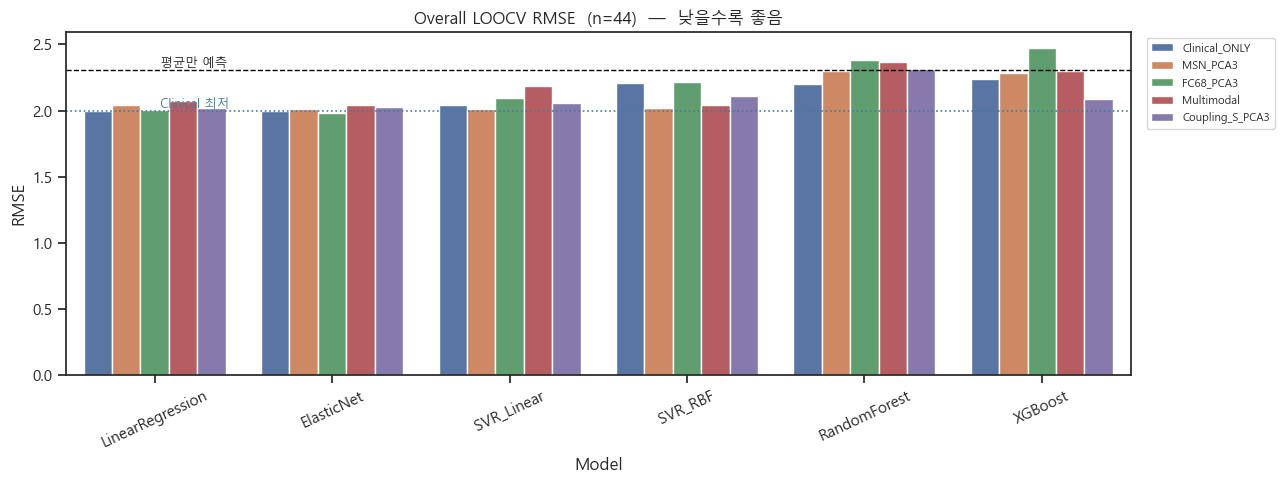

In [7]:
# ==========================================================
# 6. VISUALIZATION
# ==========================================================
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ov_long = res[res.Scope == 'Overall']
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=ov_long, x='Model', y='RMSE', hue='Data Type', hue_order=DATA_TYPES, ax=ax)
ax.axhline(baseline_rmse, color='black', ls='--', lw=1)
ax.text(0.01, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
clin = ov_long.loc[ov_long['Data Type'] == 'Clinical_ONLY', 'RMSE'].min()
ax.axhline(clin, color='#457B9D', ls=':', lw=1.2)
ax.text(0.01, clin, ' Clinical 최저', va='bottom', fontsize=9, color='#457B9D')
ax.set_title('Overall LOOCV RMSE  (n=44)  —  낮을수록 좋음')
ax.tick_params(axis='x', rotation=25)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 7. 하이퍼파라미터 안정성
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{dt} / {name}] 고유 {len(vc)}개, 최빈 {share:.0%}{flag}")

[Clinical_ONLY / LinearRegression] 고유 1개, 최빈 100%
[Clinical_ONLY / ElasticNet] 고유 1개, 최빈 100%
[Clinical_ONLY / SVR_Linear] 고유 12개, 최빈 43%   <-- 불안정
[Clinical_ONLY / SVR_RBF] 고유 7개, 최빈 84%
[Clinical_ONLY / RandomForest] 고유 5개, 최빈 61%
[Clinical_ONLY / XGBoost] 고유 4개, 최빈 86%
[MSN_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[MSN_PCA3 / ElasticNet] 고유 6개, 최빈 86%
[MSN_PCA3 / SVR_Linear] 고유 5개, 최빈 30%   <-- 불안정
[MSN_PCA3 / SVR_RBF] 고유 2개, 최빈 95%
[MSN_PCA3 / RandomForest] 고유 4개, 최빈 50%
[MSN_PCA3 / XGBoost] 고유 3개, 최빈 57%
[FC68_PCA3 / LinearRegression] 고유 1개, 최빈 100%
[FC68_PCA3 / ElasticNet] 고유 3개, 최빈 93%
[FC68_PCA3 / SVR_Linear] 고유 10개, 최빈 39%   <-- 불안정
[FC68_PCA3 / SVR_RBF] 고유 11개, 최빈 52%
[FC68_PCA3 / RandomForest] 고유 9개, 최빈 23%   <-- 불안정
[FC68_PCA3 / XGBoost] 고유 7개, 최빈 32%   <-- 불안정
[Multimodal / LinearRegression] 고유 1개, 최빈 100%
[Multimodal / ElasticNet] 고유 7개, 최빈 73%
[Multimodal / SVR_Linear] 고유 11개, 최빈 45%   <-- 불안정
[Multimodal / SVR_RBF] 고유 6개, 최빈 70%
[Multimodal / RandomForest] 고유 7개, 최빈 36% 

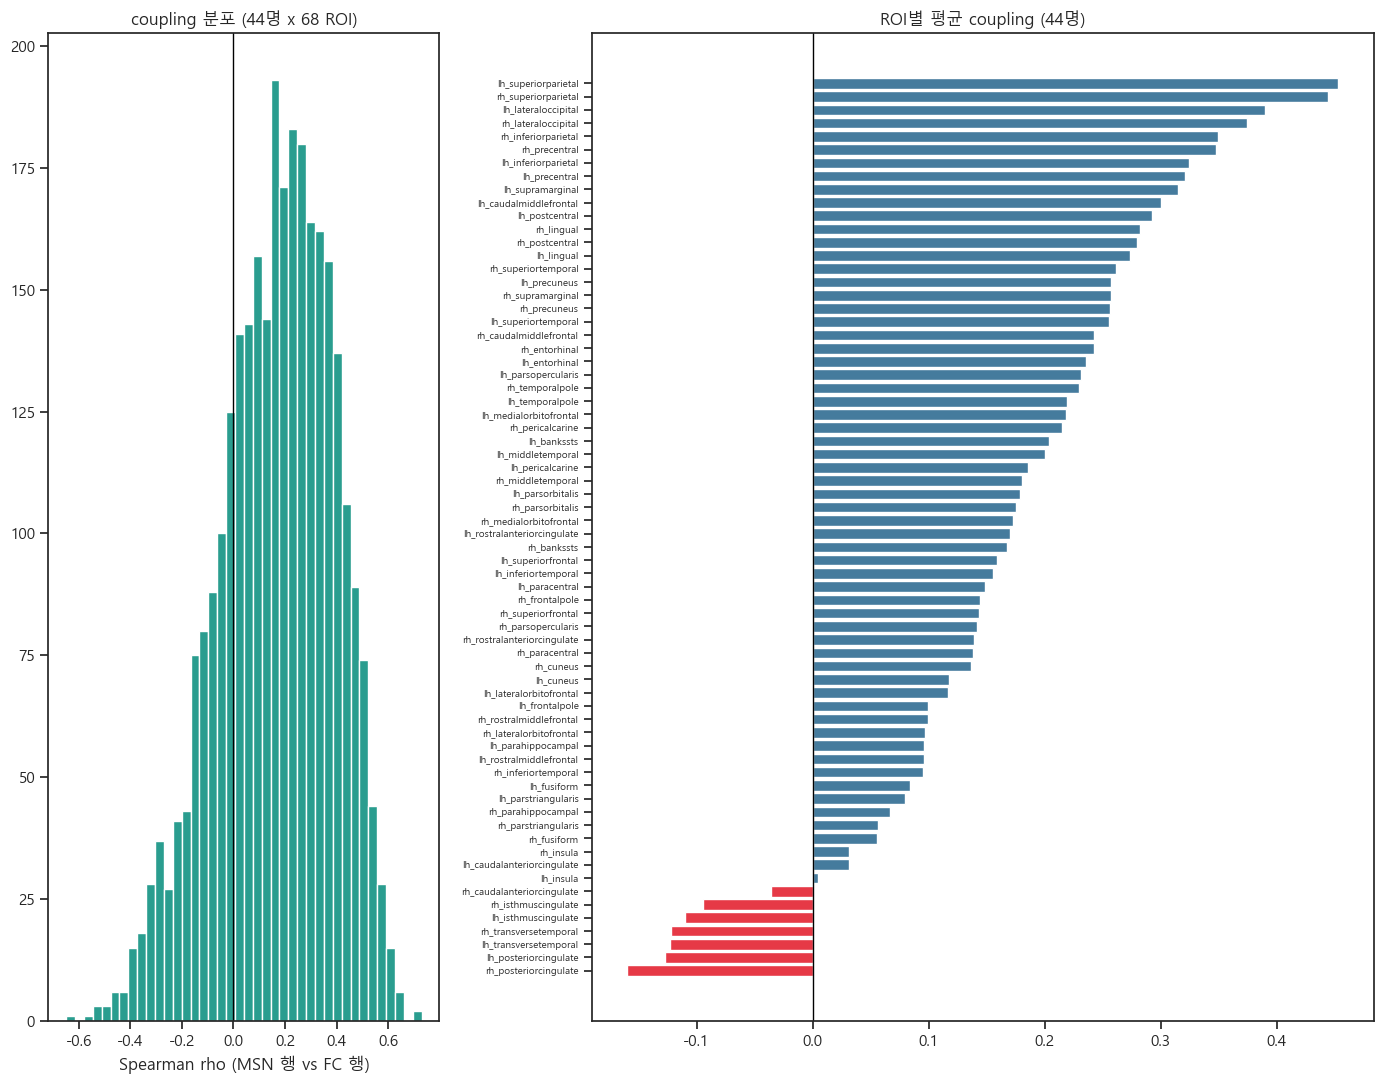

상위 5:
lh_superiorparietal    0.453
rh_superiorparietal    0.444
lh_lateraloccipital    0.390
rh_lateraloccipital    0.374
rh_inferiorparietal    0.349

하위 5:
rh_posteriorcingulate   -0.160
lh_posteriorcingulate   -0.128
lh_transversetemporal   -0.122
rh_transversetemporal   -0.122
lh_isthmuscingulate     -0.110


In [9]:
# ==========================================================
# 8. Coupling 기술통계 (sanity check — 예측과 무관, vas를 쓰지 않음)
#    선행연구: 감각·시각 피질은 coupling이 높고 연합 피질(DMN 등)은 낮다.
# ==========================================================
cp = pd.DataFrame(X_coup, columns=ROIS)
roi_mean = cp.mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 11), gridspec_kw={'width_ratios': [1, 2]})
axes[0].hist(X_coup.ravel(), bins=40, color='#2A9D8F', edgecolor='white')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('coupling 분포 (44명 x 68 ROI)')
axes[0].set_xlabel('Spearman rho (MSN 행 vs FC 행)')

colors = ['#E63946' if v < 0 else '#457B9D' for v in roi_mean.values]
axes[1].barh(roi_mean.index, roi_mean.values, color=colors)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('ROI별 평균 coupling (44명)')
axes[1].tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

print('상위 5:'); print(roi_mean.tail(5)[::-1].round(3).to_string())
print('\n하위 5:'); print(roi_mean.head(5).round(3).to_string())

## 결과 읽는 법

1. **매칭된 결합이 이득인가**: `Multimodal`이 `MSN_PCA3`와 `FC68_PCA3` **둘 다**보다 낮아야 한다
   (`d_Multi_vs_MSN`, `d_Multi_vs_FC68` 둘 다 +). 한쪽만 이기면 그 모달리티 하나가 캐리한 것이다.
2. **coupling이 정보를 더하는가**: `d_Coup_vs_Clin`이 +. coupling은 매칭이 있어야만 계산되는 피처라
   이 비교가 "68×68로 맞춘 것의 가치"를 가장 직접적으로 보여준다.
3. **부호 일관성**: 6개 모델 중 몇 개가 +인지. 선형·커널(LR, EN, SVR)에서 일관 → 신뢰도 ↑,
   트리(RF, XGB)만 + → 노이즈 가능성.
4. **기준선**: `Clinical_ONLY`, 평균 예측 RMSE와 비교. 비교는 이 노트북 안에서만 한다
   (기존 morph 단독은 n=45, 기존 FC는 84 ROI라 다른 조건이다).
5. **하지 말 것**: 8번 셀에서 coupling이 튀는 ROI를 골라 피처로 쓰는 것. 같은 44명으로 고르면 leakage다.
   PCA 성분 수를 바꿔가며 돌리는 것도 같은 문제다.


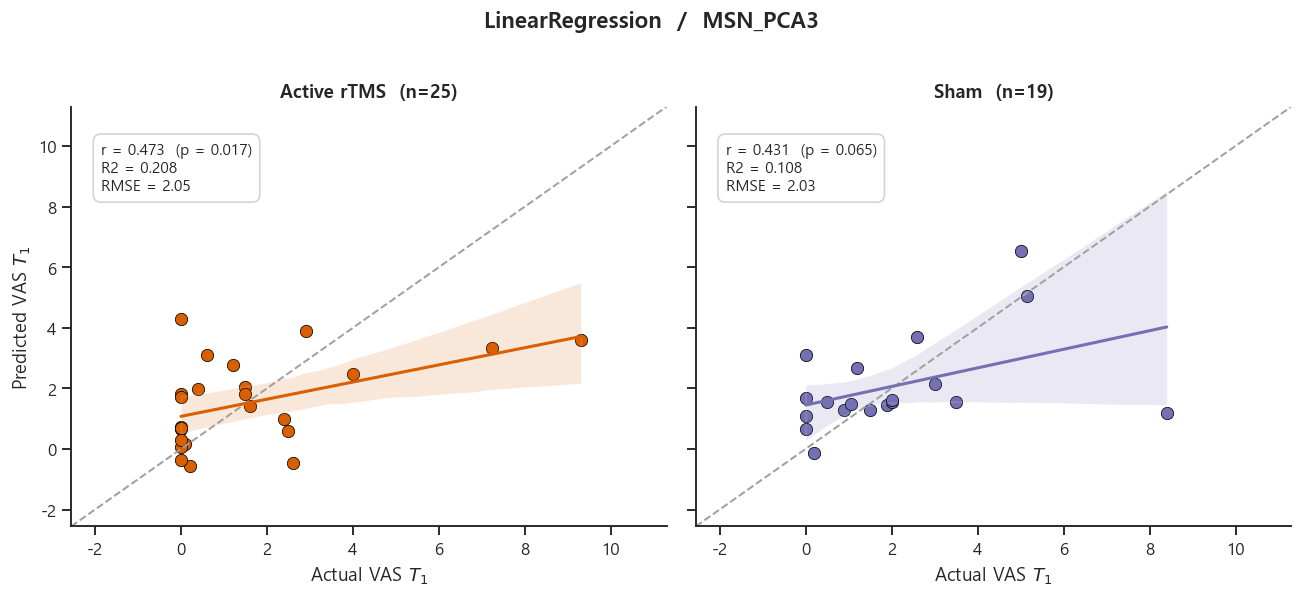

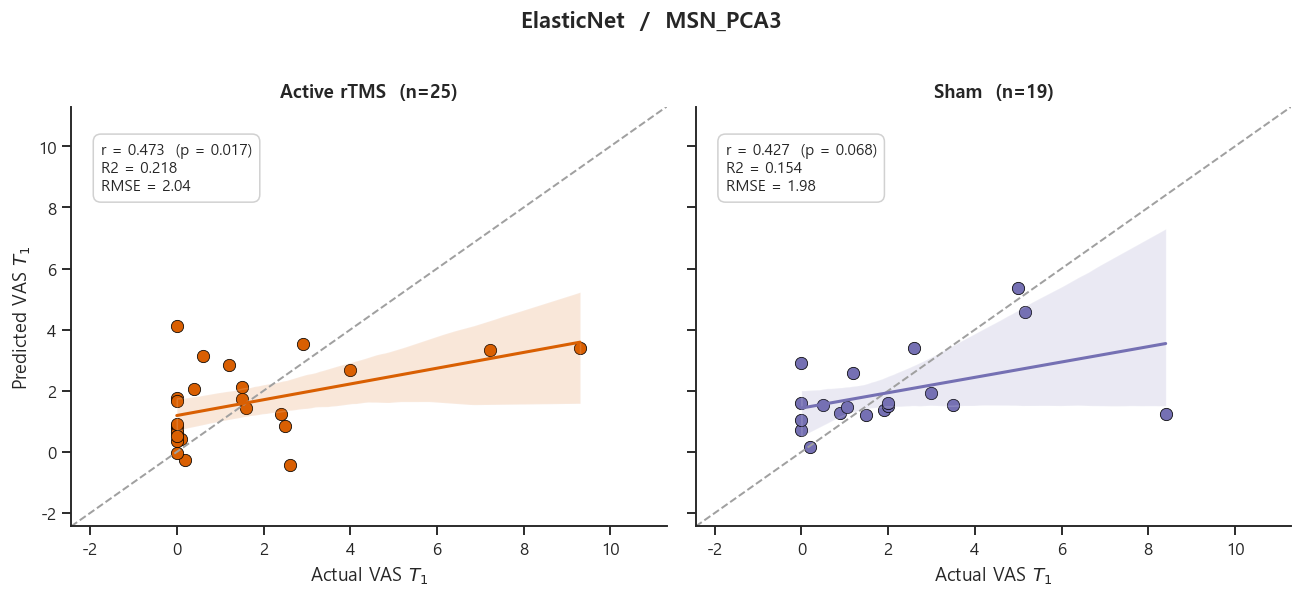

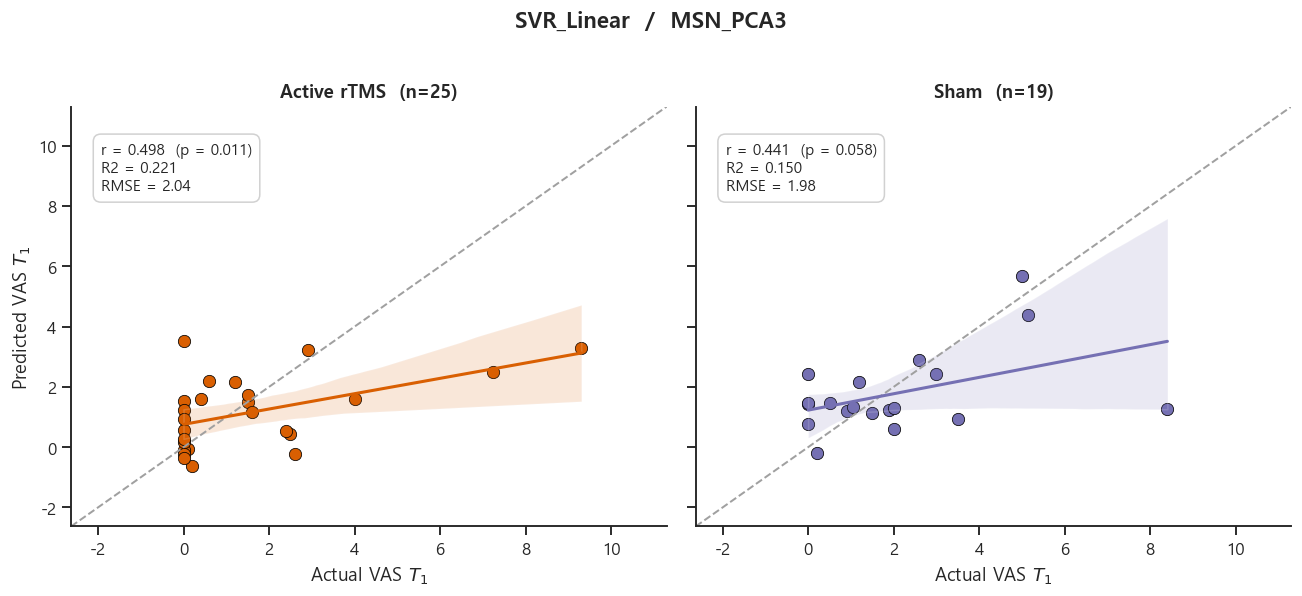

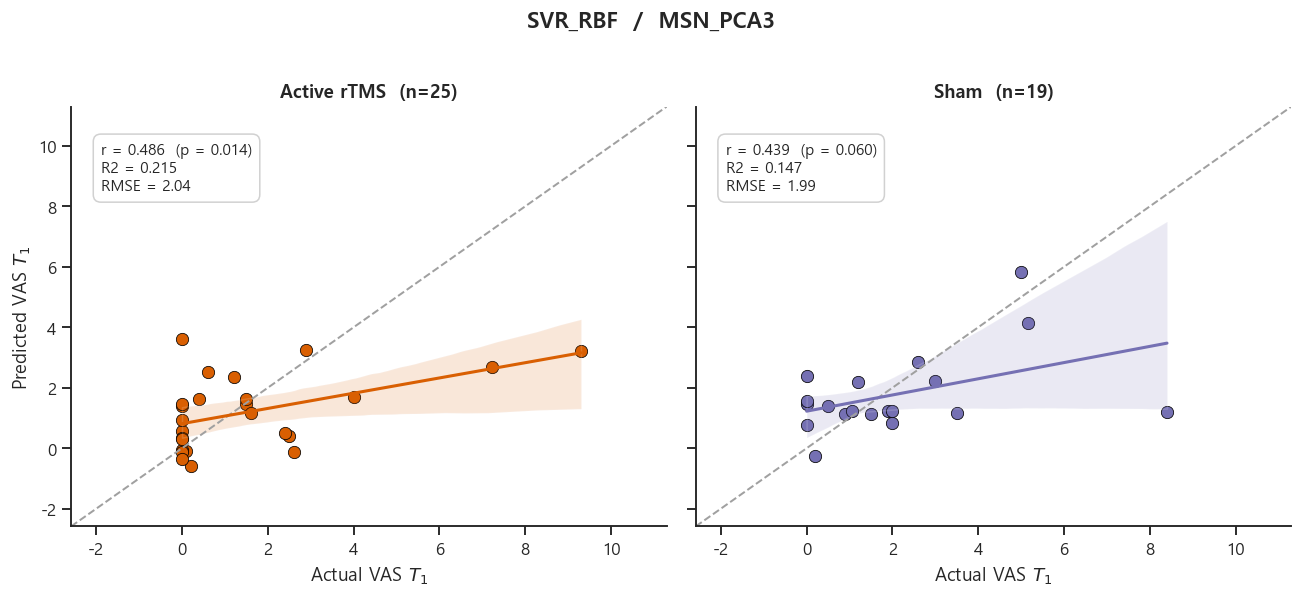

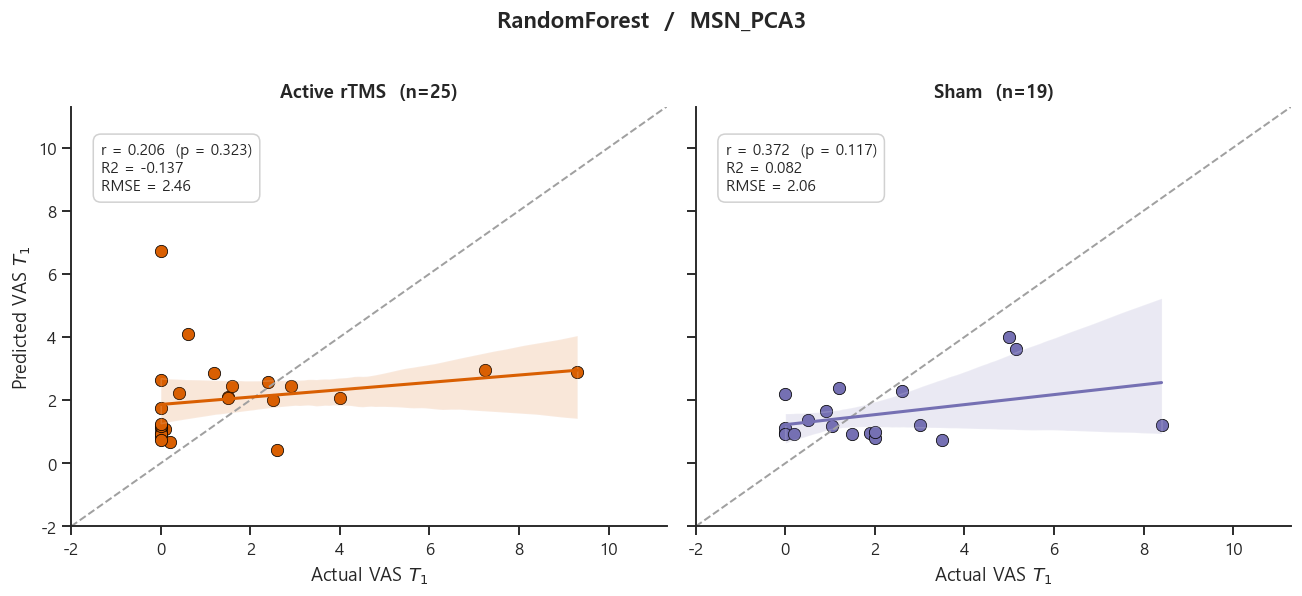

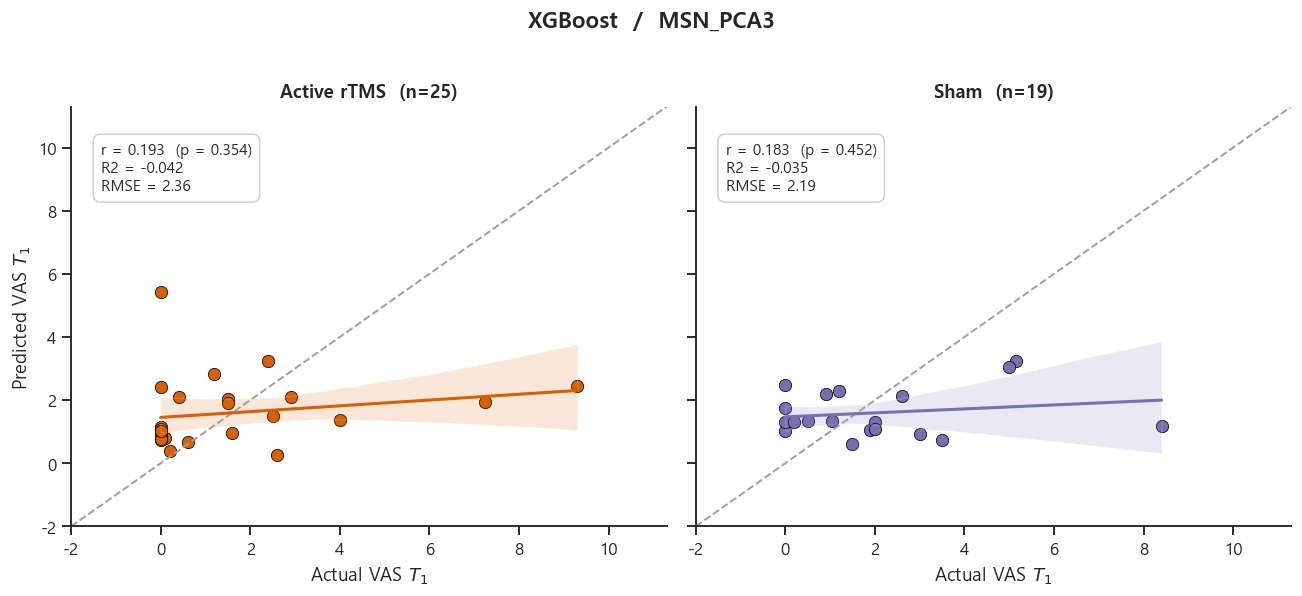

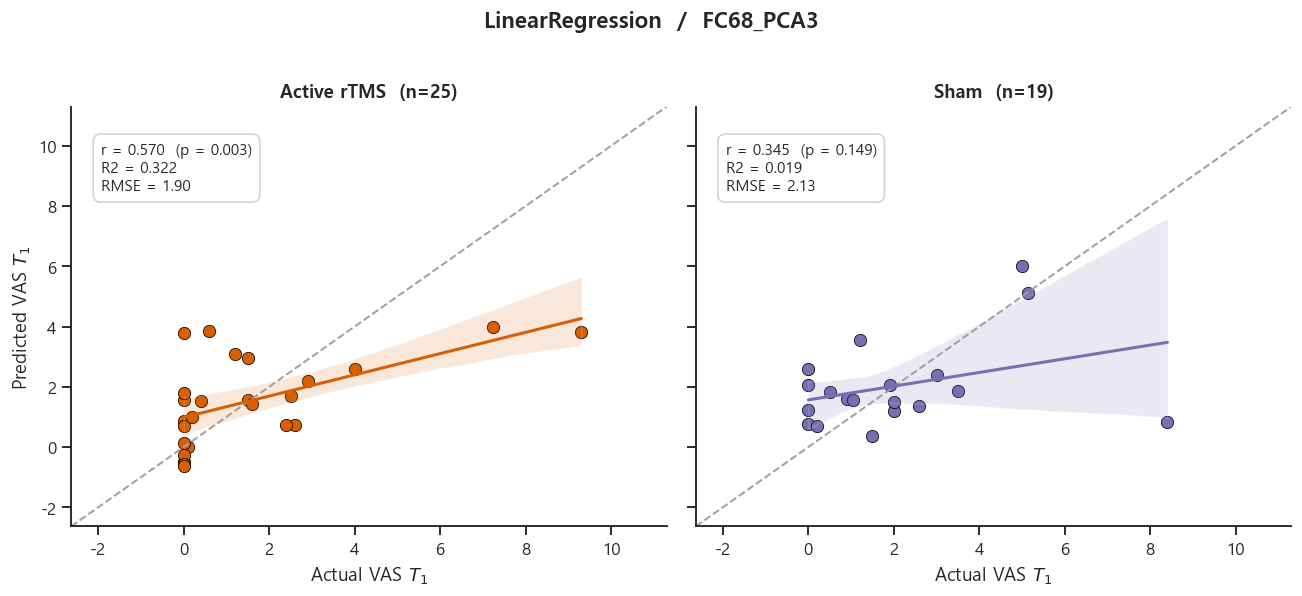

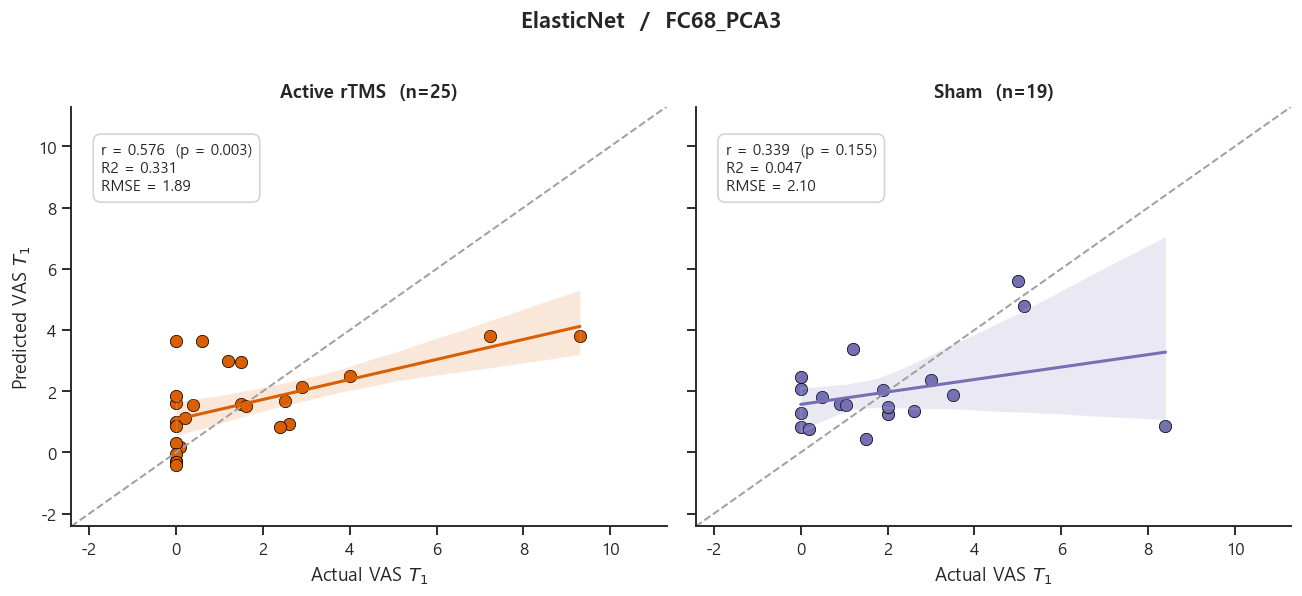

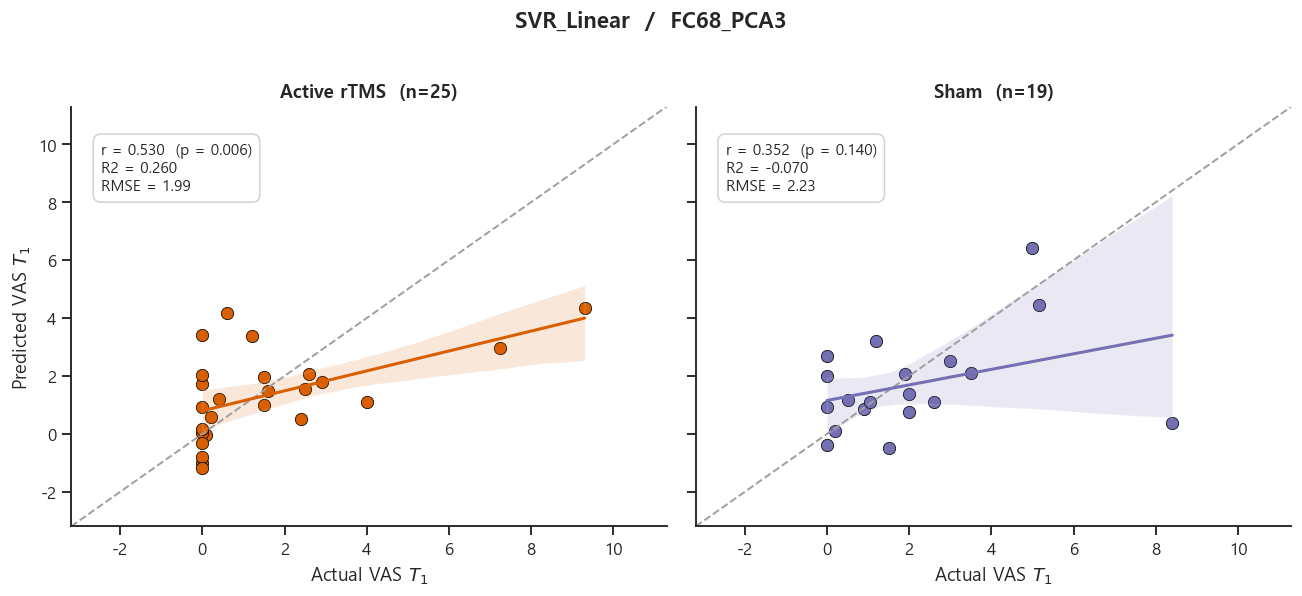

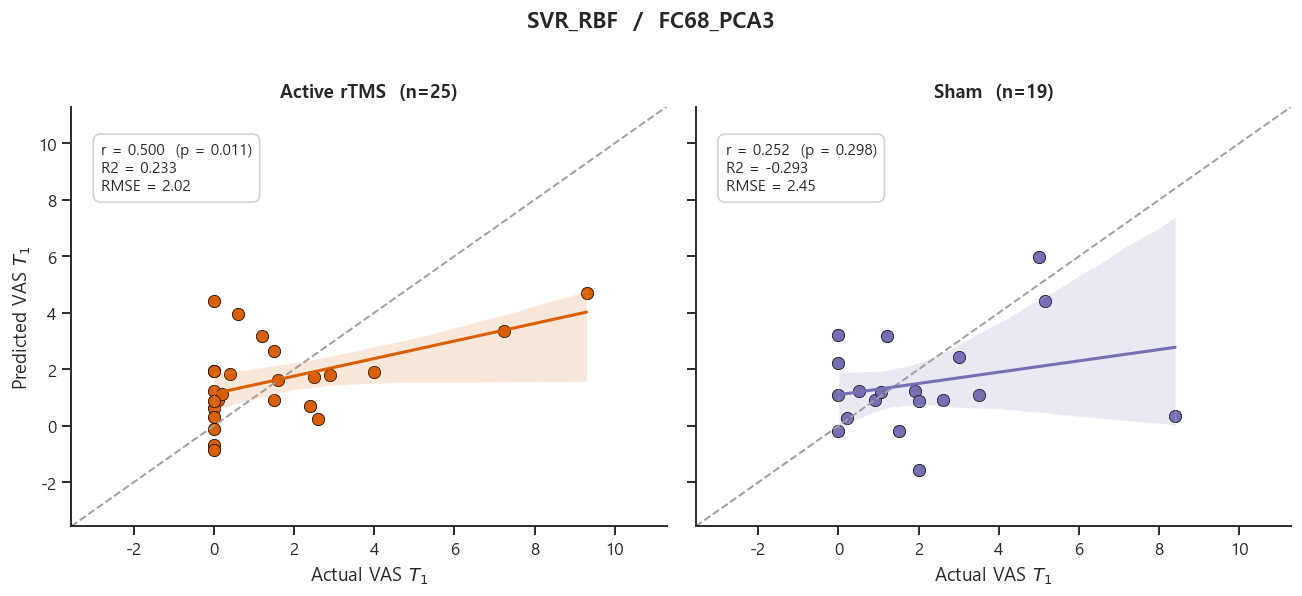

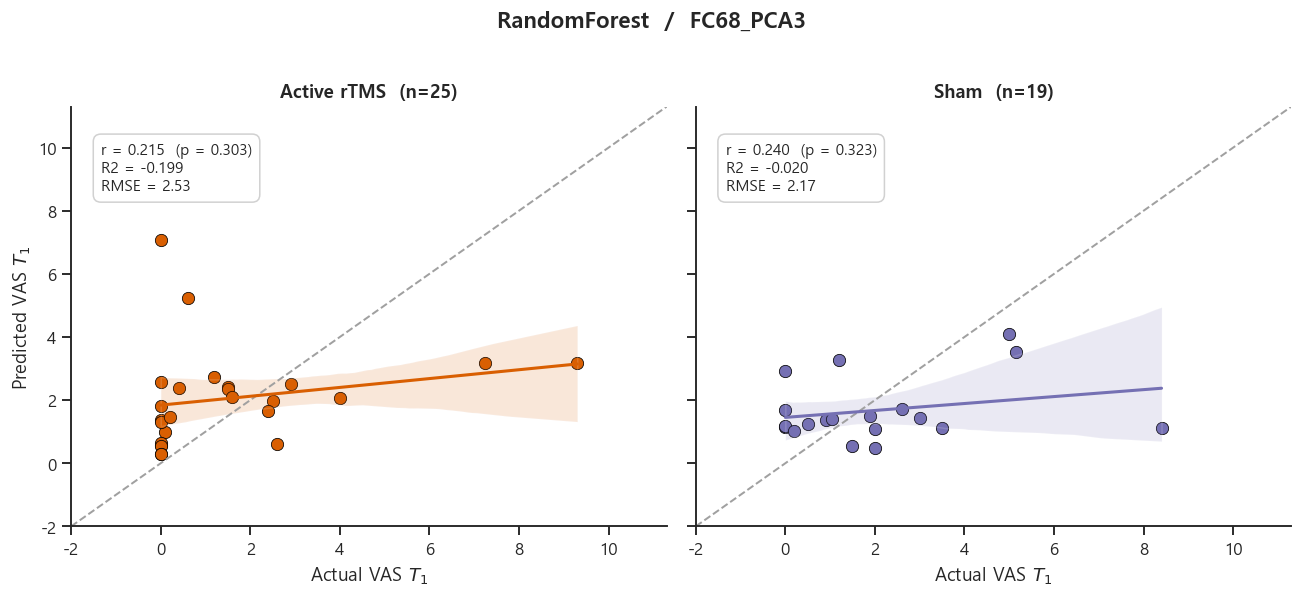

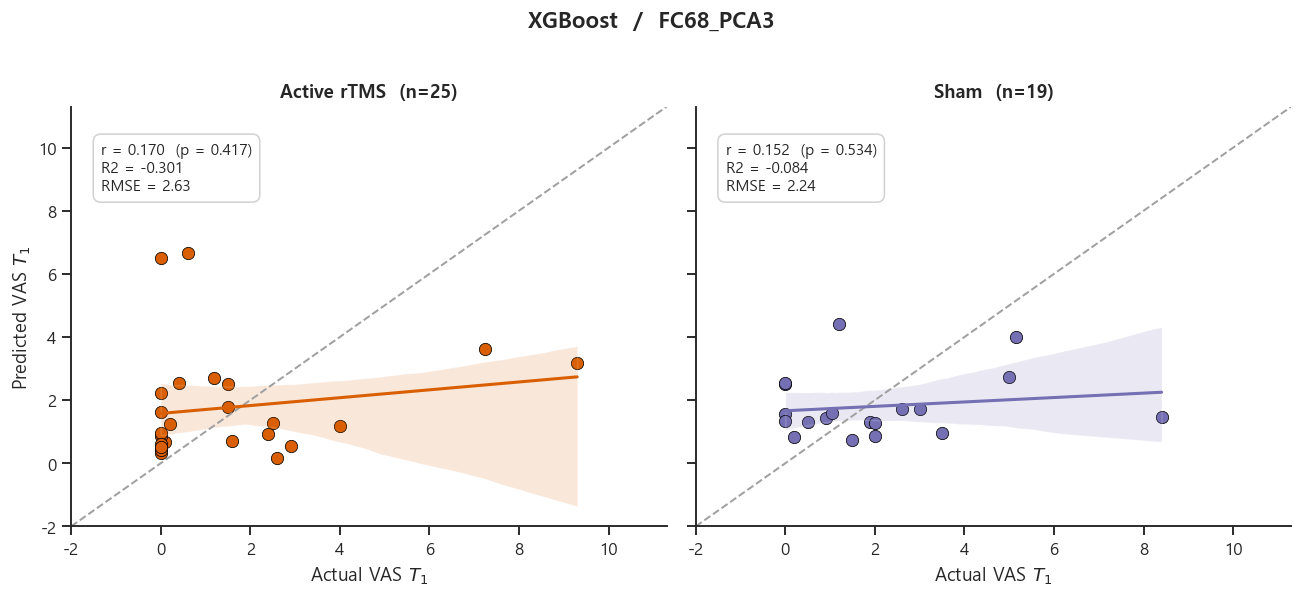

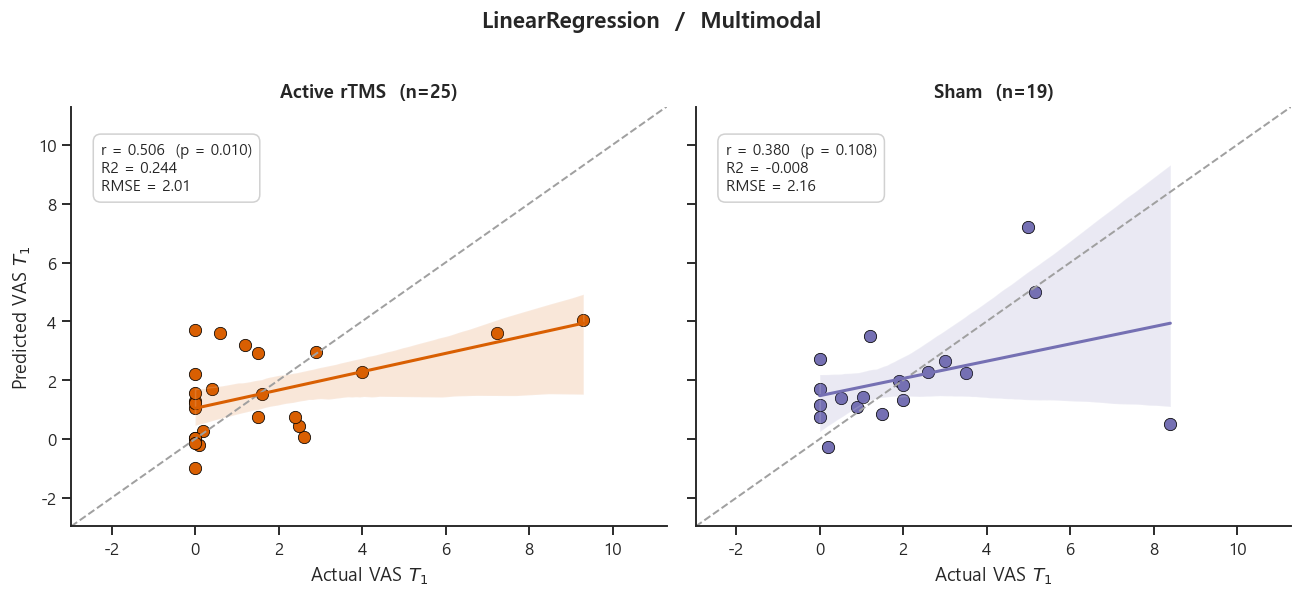

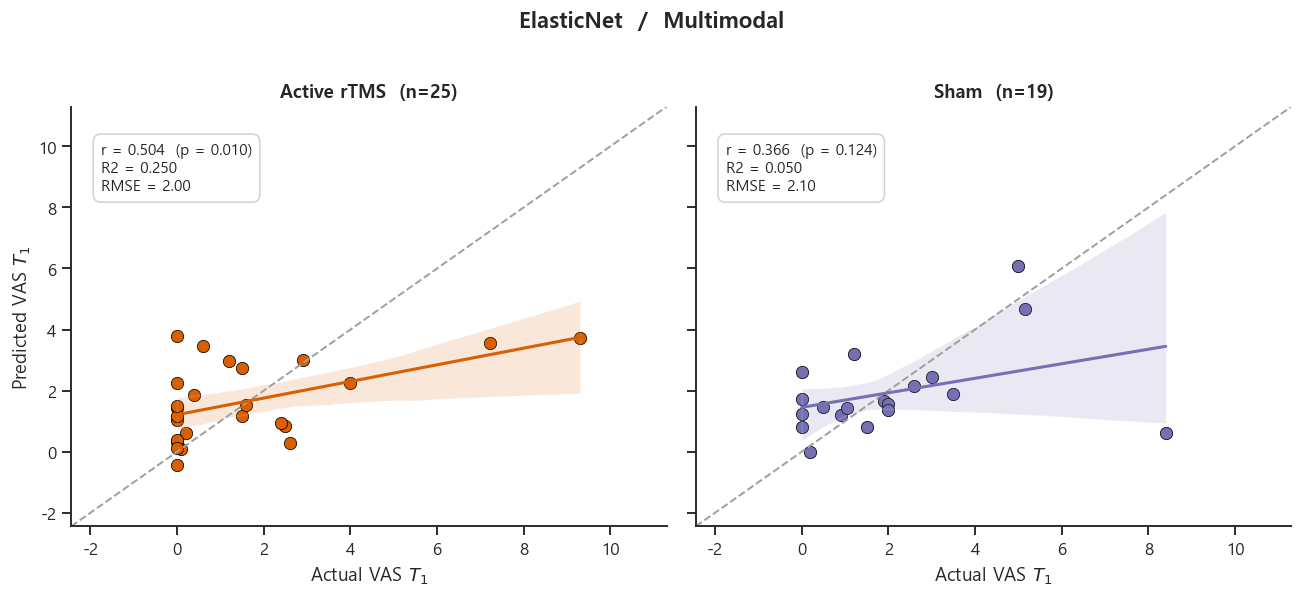

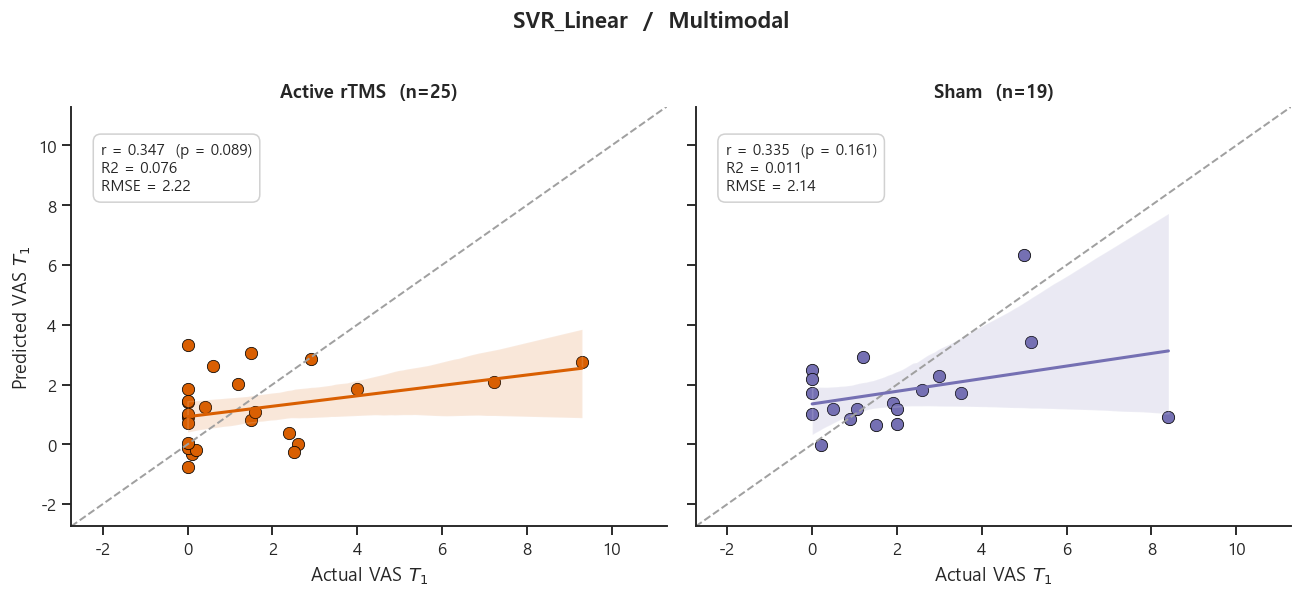

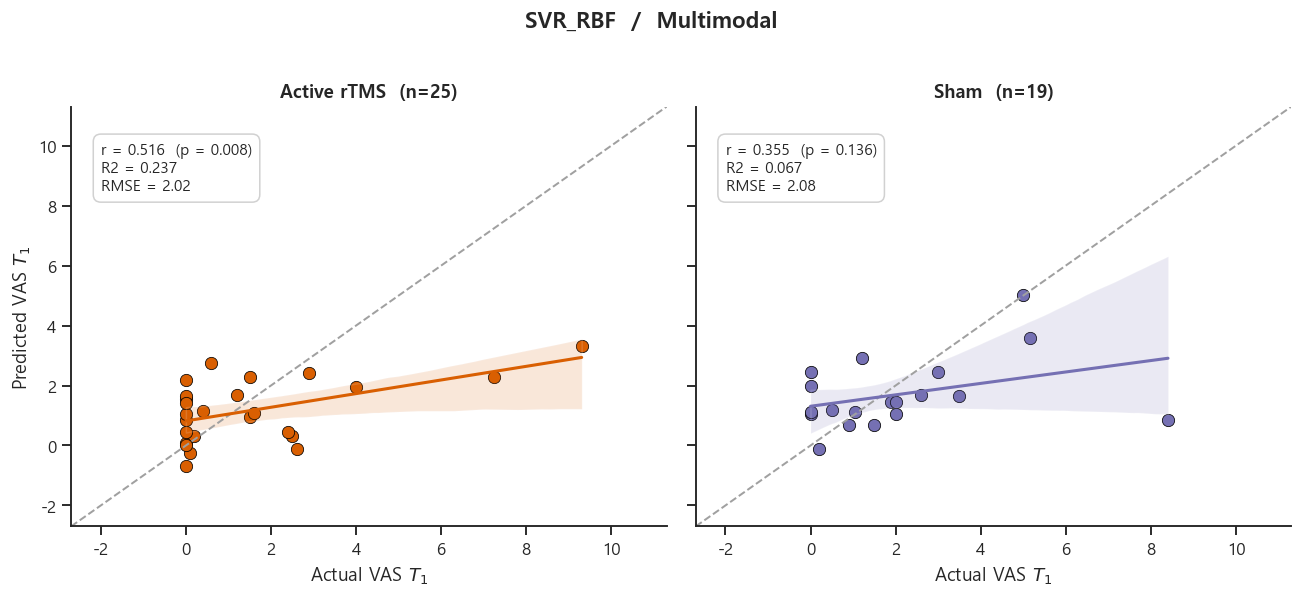

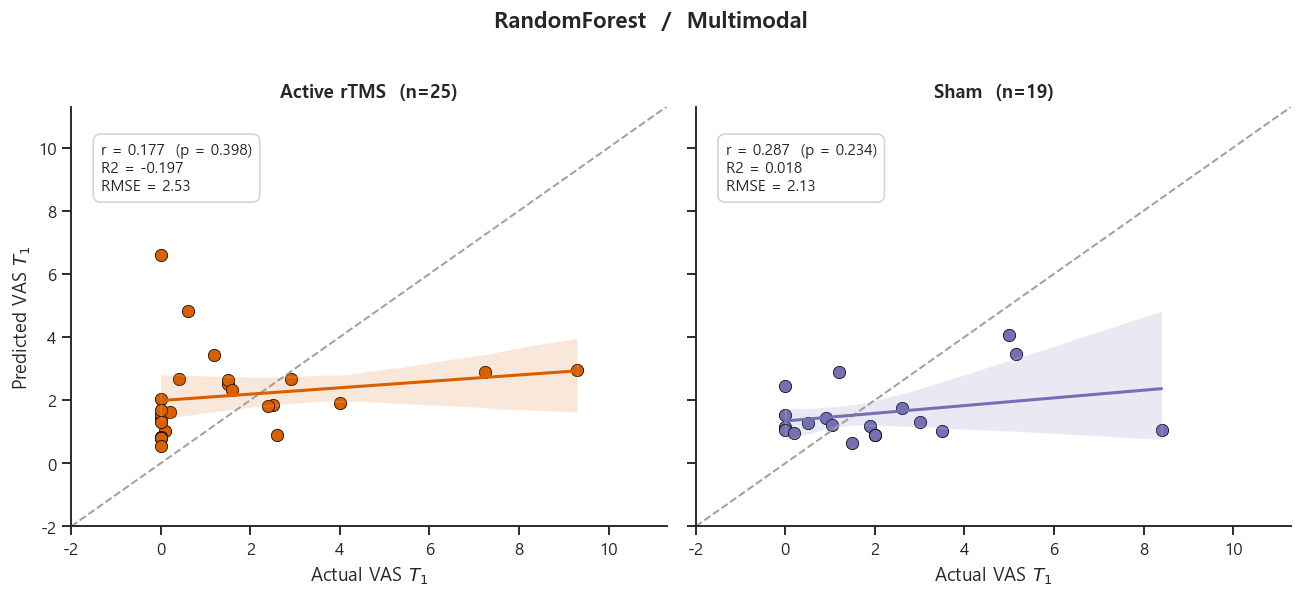

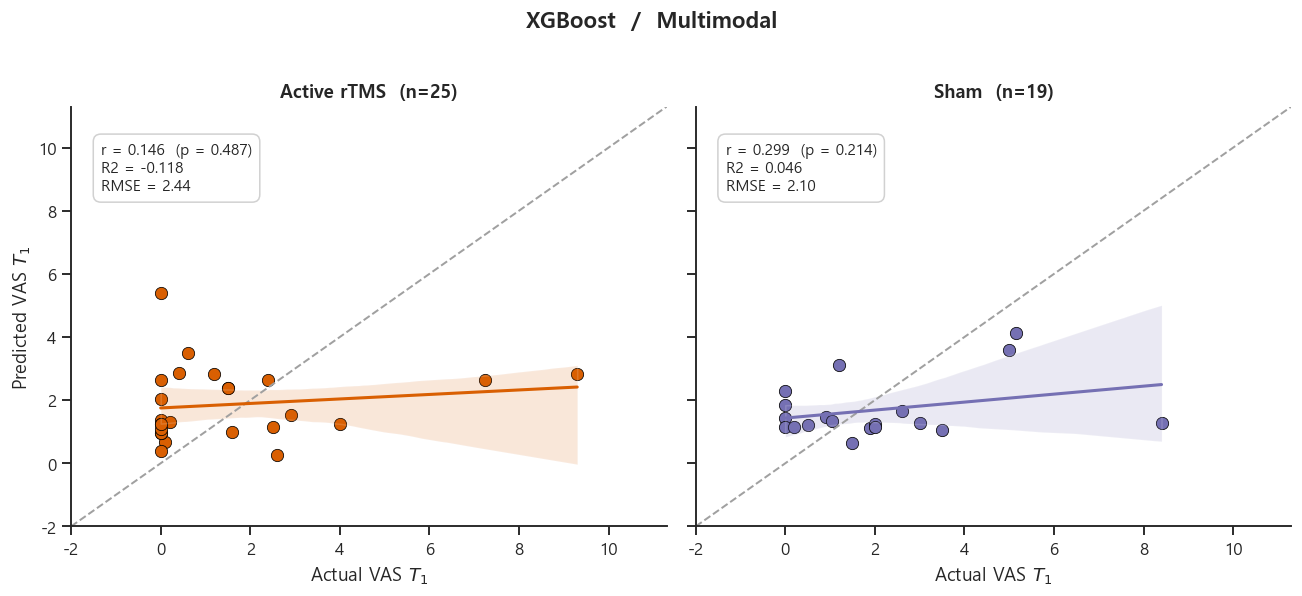

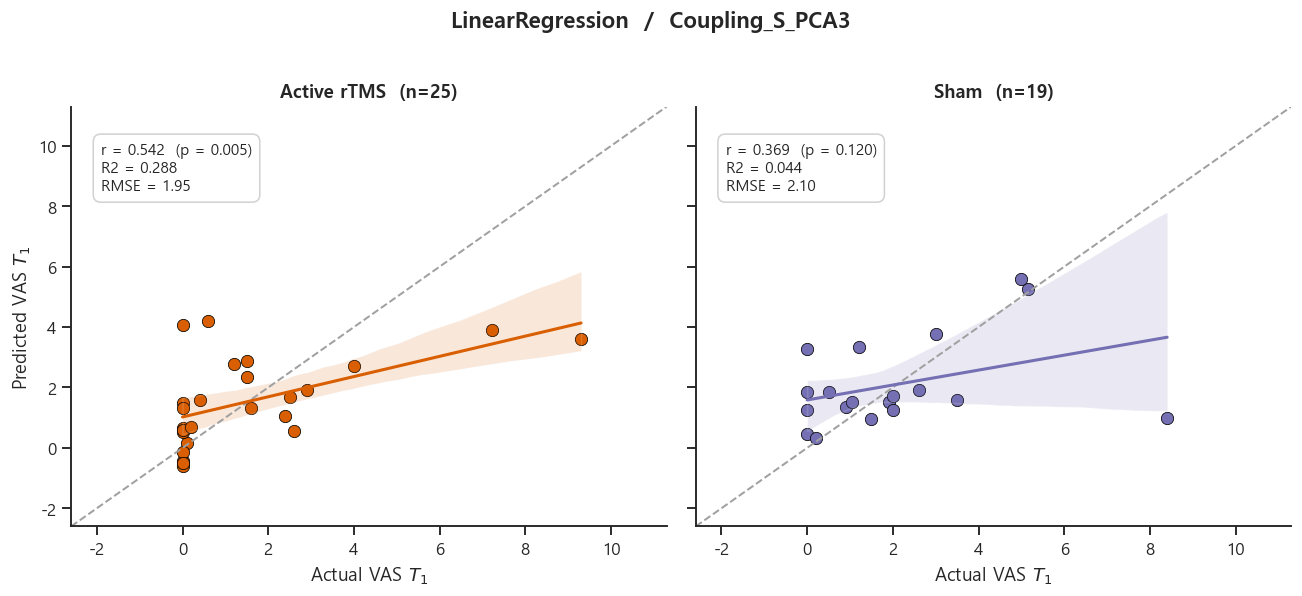

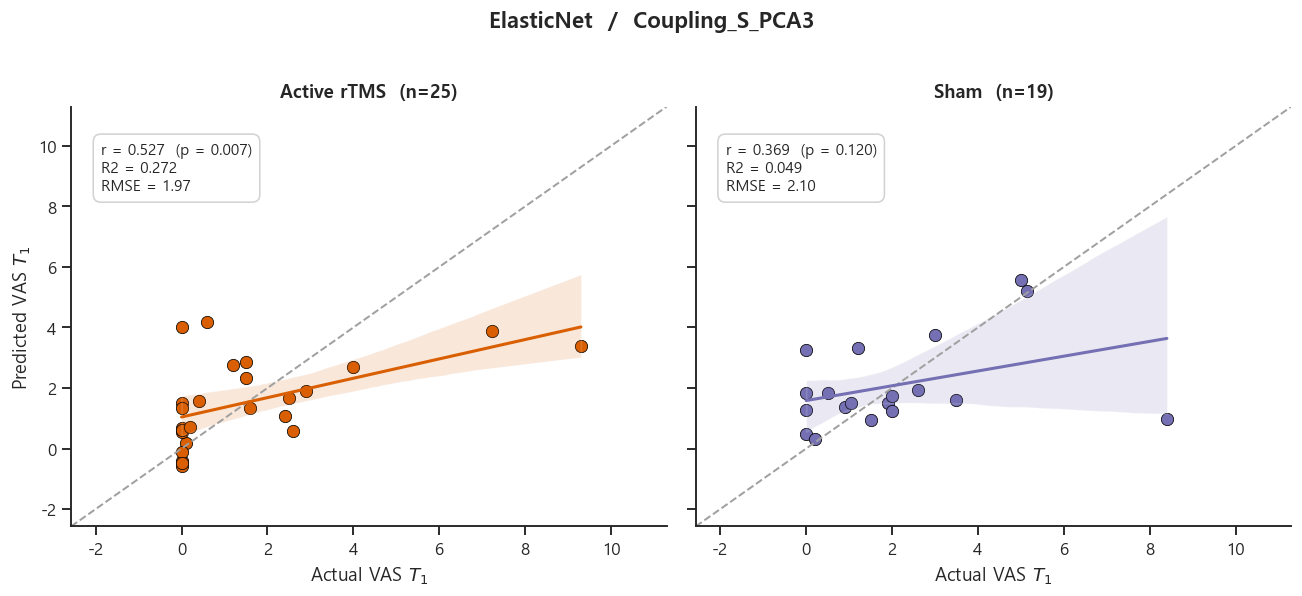

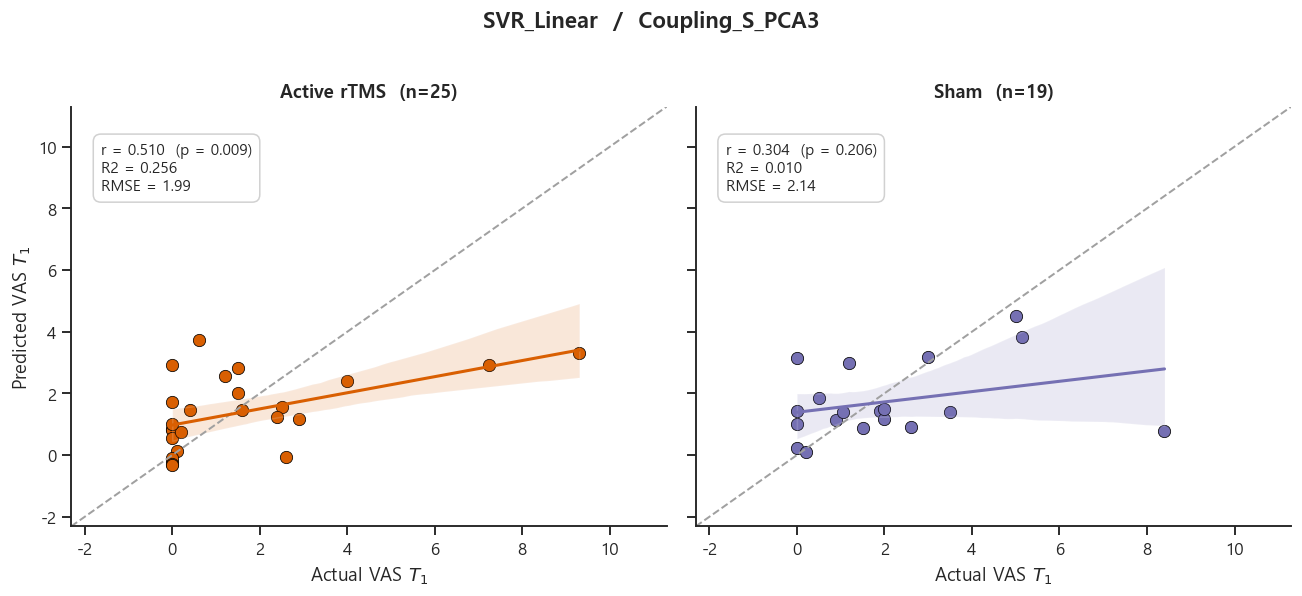

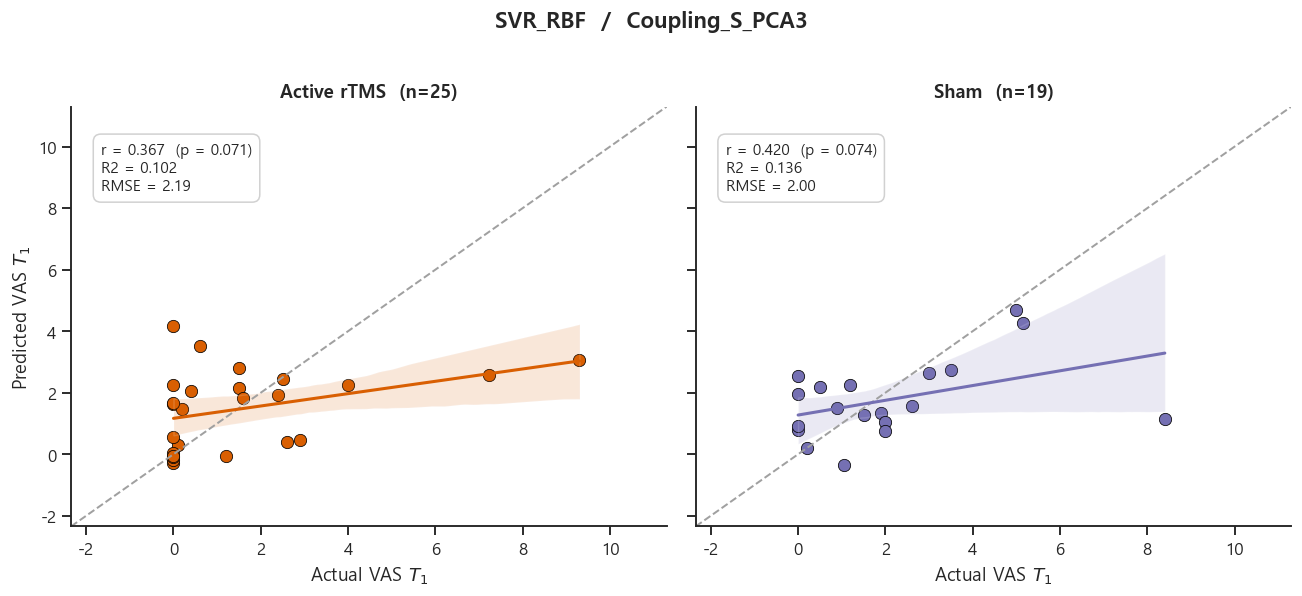

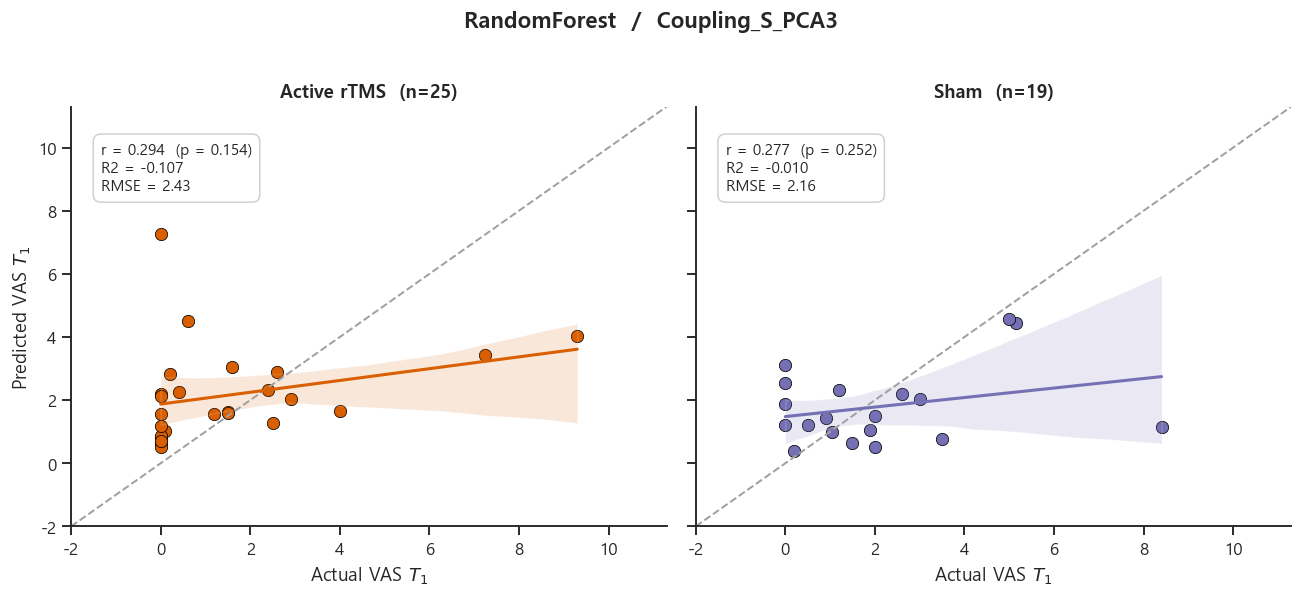

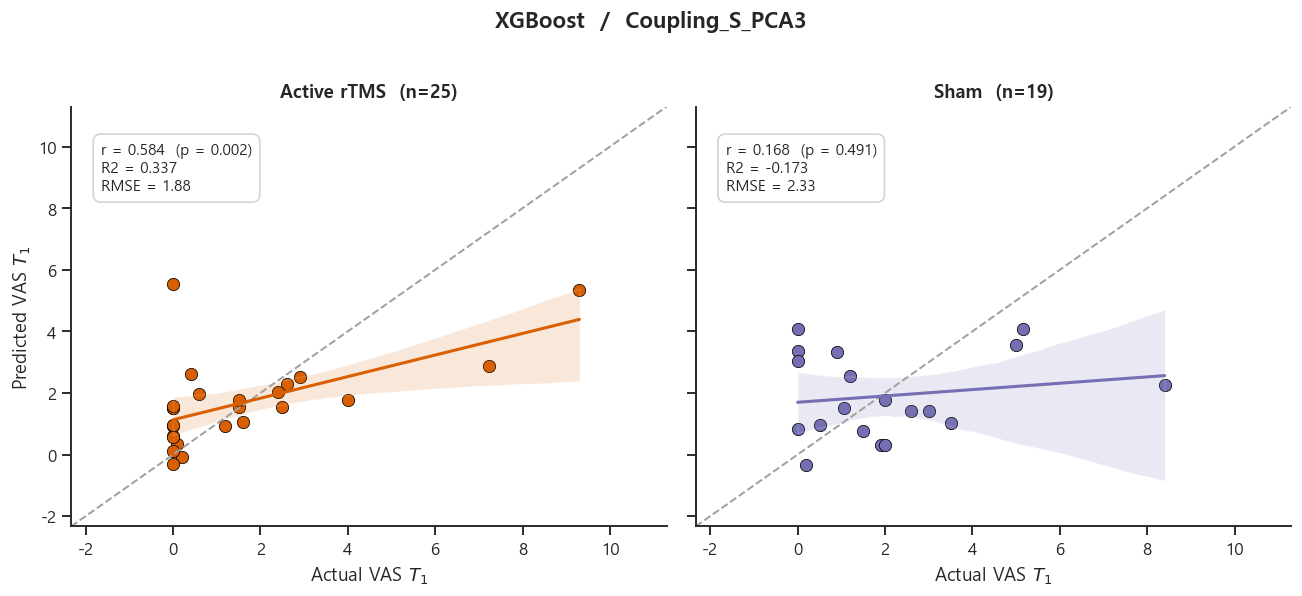

In [10]:
# ==========================================================
# 9. 산점도 — Active rTMS vs Sham 분리 (기존 멀티모달 노트북 8번 셀과 동일한 형식)
#    LOOCV 예측은 44명 전체로 학습한 것이고, 그림에서만 그룹을 나눠 본다.
# ==========================================================
PLOT_DATA_TYPES = ['MSN_PCA3', 'FC68_PCA3', 'Multimodal', 'Coupling_S_PCA3']   # 줄이려면 여기서 빼기
groups2 = ['Active rTMS', 'Sham']
palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
grp_full = np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')

for (dt, name), preds in predictions.items():
    if dt not in PLOT_DATA_TYPES:
        continue
    yp = np.array(preds)
    pdf = pd.DataFrame({'Actual': y_true, 'Predicted': yp, 'Group': grp_full})
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.3), sharex=True, sharey=True, dpi=110)
    lo = min(pdf['Actual'].min(), pdf['Predicted'].min()) - 2
    hi = max(pdf['Actual'].max(), pdf['Predicted'].max()) + 2
    for i, g in enumerate(groups2):
        ax = axes[i]
        sub = pdf[pdf['Group'] == g]
        r, pv = pearsonr(sub['Actual'], sub['Predicted'])
        ax.plot([lo, hi], [lo, hi], color='#A0A0A0', ls='--', lw=1.3)
        sns.scatterplot(data=sub, x='Actual', y='Predicted', color=palette[g], s=65,
                        edgecolor='black', linewidth=0.5, ax=ax)
        sns.regplot(data=sub, x='Actual', y='Predicted', ax=ax, scatter=False,
                    color=palette[g], line_kws={'linewidth': 2})
        ax.set_title(f'{g}  (n={len(sub)})', fontweight='bold')
        ax.text(0.05, 0.80,
                f"r = {r:.3f}  (p = {pv:.3f})\n"
                f"R2 = {r2_score(sub['Actual'], sub['Predicted']):.3f}\n"
                f"RMSE = {np.sqrt(np.mean((sub['Actual'] - sub['Predicted']) ** 2)):.2f}",
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#CCC', alpha=0.9))
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel('Actual VAS $T_1$')
        if i == 0:
            ax.set_ylabel('Predicted VAS $T_1$')
    fig.suptitle(f'{name}  /  {dt}', fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [11]:
# ==========================================================
# 10. 산점도 결과 표 — 9번 셀의 r / R2 / RMSE 를 모델별로 정리
#     (그림에 찍힌 값과 같은 숫자다. 눈으로 비교하기 어려우니 표로 모은다)
# ==========================================================
rows_sc = []
for (dt, name), preds in predictions.items():
    yp = np.array(preds)
    for g, m in [('Active', group == 'Active'), ('Sham', group == 'Sham')]:
        r, pv = pearsonr(y_true[m], yp[m])
        rows_sc.append({'Data Type': dt, 'Model': name, 'Group': g, 'n': int(m.sum()),
                        'RMSE': np.sqrt(np.mean((y_true[m] - yp[m]) ** 2)),
                        'R2': r2_score(y_true[m], yp[m]), 'r': r, 'p': pv})

sc = pd.DataFrame(rows_sc)
sc['Data Type'] = pd.Categorical(sc['Data Type'], DATA_TYPES)
sc['Model'] = pd.Categorical(sc['Model'], list(models))

# --- 넓은 표: 행 = 피처셋 x 모델, 열 = Active/Sham x 지표 ---
wide = sc.pivot_table(index=['Data Type', 'Model'], columns='Group',
                      values=['RMSE', 'R2', 'r', 'p'], observed=True)
wide = wide.swaplevel(axis=1).sort_index(axis=1, level=0)
wide = wide[[('Active', k) for k in ['RMSE', 'R2', 'r', 'p']] +
            [('Sham', k) for k in ['RMSE', 'R2', 'r', 'p']]]

print(f"Active {int((group == 'Active').sum())}명 / Sham {int((group == 'Sham').sum())}명")
print("  RMSE는 낮을수록, r은 높을수록 좋다.")
print("  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).\n")
display(wide.round(3))

# --- 좁은 표: RMSE와 r만, 두 군을 나란히 ---
print("\n========== RMSE / r 만 추려보기 ==========")
slim = wide[[('Active', 'RMSE'), ('Sham', 'RMSE'), ('Active', 'r'), ('Sham', 'r')]].copy()
slim.columns = ['RMSE_Active', 'RMSE_Sham', 'r_Active', 'r_Sham']
slim['RMSE_diff'] = slim['RMSE_Active'] - slim['RMSE_Sham']   # 음수면 Active에서 오차가 작음
display(slim.round(3))

# --- 군별로 가장 좋았던 조합 ---
print("\n========== 군별 RMSE 상위 5 ==========")
for g in ['Active', 'Sham']:
    print(f'\n[{g}]')
    display(sc[sc.Group == g].sort_values('RMSE')[['Data Type', 'Model', 'RMSE', 'R2', 'r', 'p']]
            .round(3).head(5).reset_index(drop=True))

Active 25명 / Sham 19명
  RMSE는 낮을수록, r은 높을수록 좋다.
  ※ R2는 군마다 vas 분산이 달라 군 간 직접 비교에는 쓰지 않는다 (군 안에서만 의미).



Group                            Active                        Sham         \
                                   RMSE     R2      r      p   RMSE     R2   
Data Type       Model                                                        
Clinical_ONLY   LinearRegression  2.004  0.246  0.507  0.010  1.989  0.145   
                ElasticNet        2.003  0.247  0.507  0.010  1.988  0.146   
                SVR_Linear        2.055  0.207  0.475  0.016  2.022  0.117   
                SVR_RBF           2.291  0.015  0.358  0.079  2.095  0.052   
                RandomForest      2.261  0.040  0.356  0.081  2.118  0.031   
                XGBoost           2.341 -0.029  0.319  0.120  2.089  0.058   
MSN_PCA3        LinearRegression  2.053  0.208  0.473  0.017  2.032  0.108   
                ElasticNet        2.041  0.218  0.473  0.017  1.979  0.154   
                SVR_Linear        2.037  0.221  0.498  0.011  1.984  0.150   
                SVR_RBF           2.044  0.215  0.486  0.014  1.987  0.147   
                RandomForest      2.461 -0.137  0.206  0.323  2.062  0.082   
                XGBoost           2.356 -0.042  0.193  0.354  2.189 -0.035   
FC68_PCA3       LinearRegression  1.900  0.322  0.570  0.003  2.131  0.019   
                ElasticNet        1.888  0.331  0.576  0.003  2.100  0.047   
                SVR_Linear        1.986  0.260  0.530  0.006  2.226 -0.070   
                SVR_RBF           2.021  0.233  0.500  0.011  2.446 -0.293   
                RandomForest      2.527 -0.199  0.215  0.303  2.173 -0.020   
                XGBoost           2.633 -0.301  0.170  0.417  2.240 -0.084   
Multimodal      LinearRegression  2.007  0.244  0.506  0.010  2.160 -0.008   
                ElasticNet        1.998  0.250  0.504  0.010  2.097  0.050   
                SVR_Linear        2.218  0.076  0.347  0.089  2.140  0.011   
                SVR_RBF           2.016  0.237  0.516  0.008  2.078  0.067   
                RandomForest      2.526 -0.197  0.177  0.398  2.133  0.018   
                XGBoost           2.440 -0.118  0.146  0.487  2.101  0.046   
Coupling_S_PCA3 LinearRegression  1.948  0.288  0.542  0.005  2.103  0.044   
                ElasticNet        1.969  0.272  0.527  0.007  2.098  0.049   
                SVR_Linear        1.991  0.256  0.510  0.009  2.141  0.010   
                SVR_RBF           2.187  0.102  0.367  0.071  2.000  0.136   
                RandomForest      2.428 -0.107  0.294  0.154  2.162 -0.010   
                XGBoost           1.879  0.337  0.584  0.002  2.330 -0.173   

Group                                           
                                      r      p  
Data Type       Model                           
Clinical_ONLY   LinearRegression  0.402  0.088  
                ElasticNet        0.402  0.088  
                SVR_Linear        0.400  0.090  
                SVR_RBF           0.329  0.170  
                RandomForest      0.302  0.209  
                XGBoost           0.307  0.202  
MSN_PCA3        LinearRegression  0.431  0.065  
                ElasticNet        0.427  0.068  
                SVR_Linear        0.441  0.058  
                SVR_RBF           0.439  0.060  
                RandomForest      0.372  0.117  
                XGBoost           0.183  0.452  
FC68_PCA3       LinearRegression  0.345  0.149  
                ElasticNet        0.339  0.155  
                SVR_Linear        0.352  0.140  
                SVR_RBF           0.252  0.298  
                RandomForest      0.240  0.323  
                XGBoost           0.152  0.534  
Multimodal      LinearRegression  0.380  0.108  
                ElasticNet        0.366  0.124  
                SVR_Linear        0.335  0.161  
                SVR_RBF           0.355  0.136  
                RandomForest      0.287  0.234  
                XGBoost           0.299  0.214  
Coupling_S_PCA3 LinearRegression  0.369  0.120  
                ElasticNet        0.369  0.120  
    


========== RMSE / r 만 추려보기 ==========


RMSE_Active  RMSE_Sham  r_Active  r_Sham  \
Data Type       Model                                                        
Clinical_ONLY   LinearRegression        2.004      1.989     0.507   0.402   
                ElasticNet              2.003      1.988     0.507   0.402   
                SVR_Linear              2.055      2.022     0.475   0.400   
                SVR_RBF                 2.291      2.095     0.358   0.329   
                RandomForest            2.261      2.118     0.356   0.302   
                XGBoost                 2.341      2.089     0.319   0.307   
MSN_PCA3        LinearRegression        2.053      2.032     0.473   0.431   
                ElasticNet              2.041      1.979     0.473   0.427   
                SVR_Linear              2.037      1.984     0.498   0.441   
                SVR_RBF                 2.044      1.987     0.486   0.439   
                RandomForest            2.461      2.062     0.206   0.372   
                XGBoost                 2.356      2.189     0.193   0.183   
FC68_PCA3       LinearRegression        1.900      2.131     0.570   0.345   
                ElasticNet              1.888      2.100     0.576   0.339   
                SVR_Linear              1.986      2.226     0.530   0.352   
                SVR_RBF                 2.021      2.446     0.500   0.252   
                RandomForest            2.527      2.173     0.215   0.240   
                XGBoost                 2.633      2.240     0.170   0.152   
Multimodal      LinearRegression        2.007      2.160     0.506   0.380   
                ElasticNet              1.998      2.097     0.504   0.366   
                SVR_Linear              2.218      2.140     0.347   0.335   
                SVR_RBF                 2.016      2.078     0.516   0.355   
                RandomForest            2.526      2.133     0.177   0.287   
                XGBoost                 2.440      2.101     0.146   0.299   
Coupling_S_PCA3 LinearRegression        1.948      2.103     0.542   0.369   
                ElasticNet              1.969      2.098     0.527   0.369   
                SVR_Linear              1.991      2.141     0.510   0.304   
                SVR_RBF                 2.187      2.000     0.367   0.420   
                RandomForest            2.428      2.162     0.294   0.277   
                XGBoost                 1.879      2.330     0.584   0.168   

                                  RMSE_diff  
Data Type       Model                        
Clinical_ONLY   LinearRegression      0.015  
                ElasticNet            0.015  
                SVR_Linear            0.033  
                SVR_RBF               0.196  
                RandomForest          0.143  
                XGBoost               0.252  
MSN_PCA3        LinearRegression      0.021  
                ElasticNet            0.063  
                SVR_Linear            0.053  
                SVR_RBF               0.057  
                RandomForest          0.399  
                XGBoost               0.167  
FC68_PCA3       LinearRegression     -0.230  
                ElasticNet           -0.213  
                SVR_Linear           -0.240  
                SVR_RBF              -0.425  
                RandomForest          0.354  
                XGBoost               0.393  
Multimodal      LinearRegression     -0.153  
                ElasticNet           -0.099  
                SVR_Linear            0.078  
                SVR_RBF              -0.062  
                RandomForest          0.393  
                XGBoost               0.339  
Coupling_S_PCA3 LinearRegression     -0.155  
                ElasticNet           -0.129  
                SVR_Linear           -0.150  
                SVR_RBF               0.187  
                RandomForest          0.266  
                XGBoost              -0.451


========== 군별 RMSE 상위 5 ==========

[Active]


,Data Type,Model,RMSE,R2,r,p
0,Coupling_S_PCA3,XGBoost,1.879,0.337,0.584,0.002
1,FC68_PCA3,ElasticNet,1.888,0.331,0.576,0.003
2,FC68_PCA3,LinearRegression,1.900,0.322,0.570,0.003
3,Coupling_S_PCA3,LinearRegression,1.948,0.288,0.542,0.005
4,Coupling_S_PCA3,ElasticNet,1.969,0.272,0.527,0.007



[Sham]


,Data Type,Model,RMSE,R2,r,p
0,MSN_PCA3,ElasticNet,1.979,0.154,0.427,0.068
1,MSN_PCA3,SVR_Linear,1.984,0.150,0.441,0.058
2,MSN_PCA3,SVR_RBF,1.987,0.147,0.439,0.060
3,Clinical_ONLY,ElasticNet,1.988,0.146,0.402,0.088
4,Clinical_ONLY,LinearRegression,1.989,0.145,0.402,0.088
